**Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Install & Import**

In [2]:
!pip install xgboost

import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

**Load Your Split Data**

In [3]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/c01-price-forecasting/data/model_inputs/xgboost/"

X_train = pd.read_csv(BASE_PATH + "X_train.csv")
X_test  = pd.read_csv(BASE_PATH + "X_test.csv")

y_train = pd.read_csv(BASE_PATH + "y_train.csv").values.ravel()
y_test  = pd.read_csv(BASE_PATH + "y_test.csv").values.ravel()

print("Data loaded successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data loaded successfully
X_train shape: (1844, 23)
X_test shape: (464, 23)
y_train shape: (1844,)
y_test shape: (464,)


**Sanity Check**

In [4]:
print("Sample y_train:", y_train[:5])
print("Sample y_test:", y_test[:5])

Sample y_train: [37.14 36.4  35.68 34.97 34.03]
Sample y_test: [ 93.5  88.6  87.6  92.  104. ]


**Train XGBoost Model**

In [5]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


**Predictions**

In [6]:
y_pred = model.predict(X_test)

print("Predictions generated")

Predictions generated


**Evaluation Metrics**

In [8]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n Evaluation Results:")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)


 Evaluation Results:
RMSE: 1.2540810733389935
MAE: 0.836476329935008
MAPE: 0.7136995365087011


**Plot Predictions**

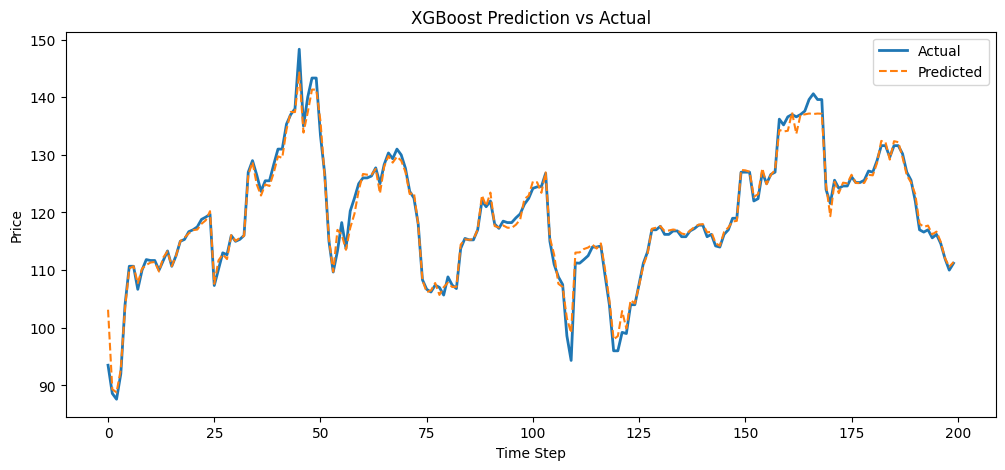

In [9]:
plt.figure(figsize=(12,5))

plt.plot(y_test[:200], label="Actual", linewidth=2)
plt.plot(y_pred[:200], label="Predicted", linestyle='--')

plt.title("XGBoost Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()

plt.show()

**Model Save**

In [10]:
import joblib

MODEL_PATH = "/content/drive/MyDrive/c01-price-forecasting/models/xgboost_model.pkl"
joblib.dump(model, MODEL_PATH)

print("Model saved")

Model saved
